In [1]:
import numpy as np
import time
from tqdm import tqdm
import matplotlib.pyplot as plt  # For visualizing input/reconstruction
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch.optim as optim
#from pytorch_msssim import ms_ssim

# S3-VAE with batch normalization:

In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Dynamically compute final feature map size
        dummy_input = torch.zeros(1, 2, img_size, img_size)  # Fake input to infer shape
        with torch.no_grad():
            dummy_output = self.conv4(self.conv3(self.conv2(self.conv1(dummy_input))))
        self.final_size = dummy_output.shape[-1]  # Get actual final size (should be 8)

        self.fc_mu = nn.Linear(256 * self.final_size * self.final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * self.final_size * self.final_size, latent_dim)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        #x = self.bn1(F.relu(self.conv1(x)))
        #x = self.bn2(F.relu(self.conv2(x)))
        #x = self.bn3(F.relu(self.conv3(x)))
        #x = self.bn4(F.relu(self.conv4(x)))

        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Decoder, self).__init__()

        # Ensure consistency with encoder
        self.final_size = 8  # Since we dynamically compute it in Encoder, we ensure it's consistent
        self.fc = nn.Linear(latent_dim, 256 * self.final_size * self.final_size)  

        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(128)

        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.deconv4 = nn.ConvTranspose2d(32, 2, kernel_size=3, stride=2, padding=1, output_padding=1)
        
        # Final Upsampling to ensure exact output size
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)


    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        x = torch.sigmoid(self.deconv4(x))  # Output is 140x140 now
        #x = self.bn1(F.relu(self.deconv1(x)))  # (128, 17, 17)
        #x = self.bn2(F.relu(self.deconv2(x)))  # (64, 35, 35)
        #x = self.bn3(F.relu(self.deconv3(x)))  # (32, 70, 70)
        #x = torch.sigmoid(self.deconv4(x)) 
        x = self.final_upsample(x)  # Ensure output size is exactly 140x140
        return x


class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    
    

# S3-VAE with maxPooling:

In [ ]:

class Encoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Encoder, self).__init__()
        self.conv1 = nn.Conv2d(2, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.MaxPool2d(2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.MaxPool2d(2)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.MaxPool2d(2)
        
        final_size = img_size // 16
        self.fc_mu = nn.Linear(256 * final_size * final_size, latent_dim)
        self.fc_logvar = nn.Linear(256 * final_size * final_size, latent_dim)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar
    
    
class Decoder(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(Decoder, self).__init__()
        
        final_size = img_size // 16
        self.fc = nn.Linear(latent_dim, 256 * final_size * final_size)
        
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1)
        self.deconv4 = nn.Conv2d(32, 2, kernel_size=3, stride=1, padding=1)
        self.final_upsample = nn.Upsample(size=(140, 140), mode='bilinear', align_corners=True)  # Ensures exact size

        
    def forward(self, z):
        final_size = 8
        x = self.fc(z)
        x = x.view(-1, 256, final_size, final_size)
        x = F.relu(self.deconv1(x))
        x = F.relu(self.deconv2(x))
        x = F.relu(self.deconv3(x))
        x = F.relu(self.deconv4(x))
        x = torch.sigmoid(self.final_upsample(x))
        return x
    
    
class VAE(nn.Module):
    def __init__(self, latent_dim=20, img_size=140):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim, img_size)
        self.decoder = Decoder(latent_dim, img_size)
        
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar
    

In [3]:
class MarkerDataset(Dataset):
    def __init__(self, marker_name, img_size=140, data_dir='B_cells_Data'):
        self.images = np.load(f"{data_dir}/{marker_name}_images.npy")  # Shape: (N, 2, H, W)
        self.labels = np.load(f"{data_dir}/{marker_name}_labels.npy")  # Shape: (N,)
        self.patient_labels = np.load(f"{data_dir}/{marker_name}_patient_labels.npy")  # Shape: (N,)
        
        # Normalize images to [0, 1] range
        self.images = self.images / 255.0
        
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size)),  # Resizing
            transforms.Normalize(mean=[0.5, 0.5], std=[0.5, 0.5])  # Normalize both channels
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]  # Shape: (2, H, W)
        label = self.labels[idx]
        patient_id = self.patient_labels[idx]
        
        img = torch.tensor(img, dtype=torch.float32)  # Convert to Tensor
        return img, label, patient_id

# Example: Load BTK dataset
btk_dataset = MarkerDataset("BTK")
btk_loader = DataLoader(btk_dataset, batch_size=32, shuffle=True)
print(f"Total batches: {len(btk_loader)}")

Total batches: 56


In [4]:
print(f"Number of images in dataset: {len(btk_dataset)}")
print(f"Number of batches in DataLoader: {len(btk_loader)}")

Number of images in dataset: 1786
Number of batches in DataLoader: 56


In [5]:
img, label, patient_id = btk_dataset[0]  # Get the first image in the dataset
print(f"Image shape: {img.shape}")       # Print shape of the image
print(f"Image max value: {img.max()}")   # Print max value
print(f"Image min value: {img.min()}")   # Print min value

# Get the maximum value across the entire dataset
dataset_max = np.max(btk_dataset.images)
print(f"Maximum value in the dataset: {dataset_max}")
print(f"Size of the dataset: {len(btk_dataset)}")

Image shape: torch.Size([2, 140, 140])
Image max value: 0.816339910030365
Image min value: 0.0
Maximum value in the dataset: 1.0
Size of the dataset: 1786


In [6]:
def visualize_reconstructions(vae, dataloader, device):
    vae.eval()
    with torch.no_grad():
        for batch in dataloader:
            images = batch[0].to(device)
            recon_images, _, _ = vae(images)
            # Visualize first 5 images and their reconstructions
            fig, axes = plt.subplots(2, 5, figsize=(15, 6))
            for i in range(5):
                # Original
                axes[0, i].imshow(images[i, 0].cpu().numpy(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")
                # Reconstructed
                axes[1, i].imshow(recon_images[i, 0].cpu().numpy(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")
            plt.show()
            break

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

#Additonal step:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [8]:
def loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE for pixel-level similarity)
    #reconstruction_loss = F.mse_loss(recon_x, x, reduction='mean')
    reconstruction_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence (latent space regularization)
    kl_divergence = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return reconstruction_loss, kl_divergence

In [9]:
# Initialize lists to store losses for plotting
total_losses = []
reconstruction_losses = []
kl_losses = []

num_epochs = 20
kl_weight = 0.001
vae.train()
#plotting losses(kl, mse) + normalize the images + return 

for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0
    
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            step_start_time = time.time()  # Start step timer

            images, _, _ = batch
            images = images.to(device)

            t0 = time.time()
            optimizer.zero_grad()  # Zero gradients
            t1 = time.time()
            zero_grad_time = t1 - t0
            #print(f"zero_grad_time: {zero_grad_time:.4f}s")
            
            recon_images, mu, logvar = vae(images)  # Forward pass
            t2 = time.time()
            forward_time = t2 - t1
            #print(f"forward_time: {forward_time:.4f}s")
            
            # Compute losses
            recon_loss, kl_loss = loss_function(recon_images, images, mu, logvar)
            
            t3 = time.time()
            loss_time = t3 - t2
            #print(f"loss_time: {loss_time:.4f}s")
            
            scaled_loss = recon_loss + kl_weight * kl_loss
            scaled_loss.backward()  # Backward pass
            t4 = time.time()
            backward_time = t4 - t3
            #print(f"backward_time: {backward_time:.4f}s")
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), max_norm=1.0)  # Gradient clipping
            t5 = time.time()
            clip_time = t5 - t4
            #print(f"clip_time: {clip_time:.4f}s")
            
            optimizer.step()  # Optimizer step
            t6 = time.time()
            optimizer_time = t6 - t5
            #print(f"optimizer_time: {optimizer_time:.4f}s")

            step_time = t6 - step_start_time

            # Print timing for each operation
            print(f"Step {batch_idx + 1} times: zero_grad={zero_grad_time:.4f}s, forward={forward_time:.4f}s, loss_calc={loss_time:.4f}s, backward={backward_time:.4f}s, clip={clip_time:.4f}s, optimize={optimizer_time:.4f}s, total={step_time:.4f}s")

            # Accumulate losses for the epoch
            epoch_total_loss += scaled_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kl_loss += kl_loss.item()
            
            tepoch.set_postfix(
                recon_loss=recon_loss.item(),
                kl_loss=kl_loss.item(),
                total_loss=scaled_loss.item()
            )

    # Calculate average losses for the epoch
    avg_total_loss = epoch_total_loss / len(btk_loader)
    avg_recon_loss = epoch_recon_loss / len(btk_loader)
    avg_kl_loss = epoch_kl_loss / len(btk_loader)

    # Store the average losses
    total_losses.append(avg_total_loss)
    reconstruction_losses.append(avg_recon_loss)
    kl_losses.append(avg_kl_loss)
    
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {avg_total_loss / len(btk_loader.dataset):.4f}")


Epoch 1:   2%|▏         | 1/56 [00:02<02:20,  2.56s/batch, kl_loss=74.9, recon_loss=2.38e+5, total_loss=2.38e+5]

Step 1 times: zero_grad=0.0015s, forward=0.9888s, loss_calc=0.0187s, backward=1.3763s, clip=0.0070s, optimize=0.0500s, total=2.4423s


Epoch 1:   4%|▎         | 2/56 [00:04<01:43,  1.91s/batch, kl_loss=1.44e+4, recon_loss=2.2e+5, total_loss=2.2e+5]

Step 2 times: zero_grad=0.0035s, forward=0.4774s, loss_calc=0.0237s, backward=0.6753s, clip=0.0249s, optimize=0.2096s, total=1.4146s


Epoch 1:   5%|▌         | 3/56 [00:05<01:35,  1.80s/batch, kl_loss=1.99e+5, recon_loss=2.09e+5, total_loss=2.09e+5]

...

Step 54 times: zero_grad=0.0046s, forward=0.3577s, loss_calc=0.0028s, backward=0.5248s, clip=0.0025s, optimize=0.0238s, total=0.9163s


Epoch 20:  98%|█████████▊| 55/56 [00:55<00:01,  1.00s/batch, kl_loss=5.46e+3, recon_loss=3.19e+3, total_loss=3.31e+3]

Step 55 times: zero_grad=0.0021s, forward=0.3423s, loss_calc=0.0124s, backward=0.5686s, clip=0.0021s, optimize=0.0327s, total=0.9603s


Epoch 20: 100%|██████████| 56/56 [00:56<00:00,  1.00s/batch, kl_loss=3.85e+3, recon_loss=2.86e+3, total_loss=2.94e+3]

Step 56 times: zero_grad=0.0020s, forward=0.2878s, loss_calc=0.0034s, backward=0.4255s, clip=0.0025s, optimize=0.0162s, total=0.7376s
Epoch 20: Loss = 1.9029


In [ ]:
num_epochs = 20
kl_weight = 0.001
vae.train()
for epoch in range(num_epochs):
    kl_weight = min(1.0, kl_weight + 0.001)  # Gradually increase KL weight
    total_loss = 0
    with tqdm(btk_loader, unit="batch") as tepoch:
        for batch_idx, batch in enumerate(tepoch):
            tepoch.set_description(f"Epoch {epoch+1}")
            step_start_time = time.time()  # Start step timer

            images, _, _ = batch
            images = images.to(device)

            t0 = time.time()
            optimizer.zero_grad()  # Zero gradients
            t1 = time.time()
            zero_grad_time = t1 - t0

            recon_images, mu, logvar = vae(images)  # Forward pass
            t2 = time.time()
            forward_time = t2 - t1

            loss, recon_loss, kl_loss = vae.loss_function(recon_images, images, mu, logvar, loss_type='ssim')  # Compute loss
            t3 = time.time()
            loss_time = t3 - t2

            loss.backward()  # Backward pass
            t4 = time.time()
            backward_time = t4 - t3

            optimizer.step()  # Optimizer step
            t5 = time.time()
            optimizer_time = t5 - t4

            step_time = t5 - step_start_time

            # Print timing for each operation
            print(f"Step {batch_idx + 1} times: zero_grad={zero_grad_time:.4f}s, forward={forward_time:.4f}s, loss_calc={loss_time:.4f}s, backward={backward_time:.4f}s, optimize={optimizer_time:.4f}s, total={step_time:.4f}s")

            total_loss += loss.item()
            tepoch.set_postfix(loss=loss.item() / len(images))

    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(btk_loader.dataset):.4f}")


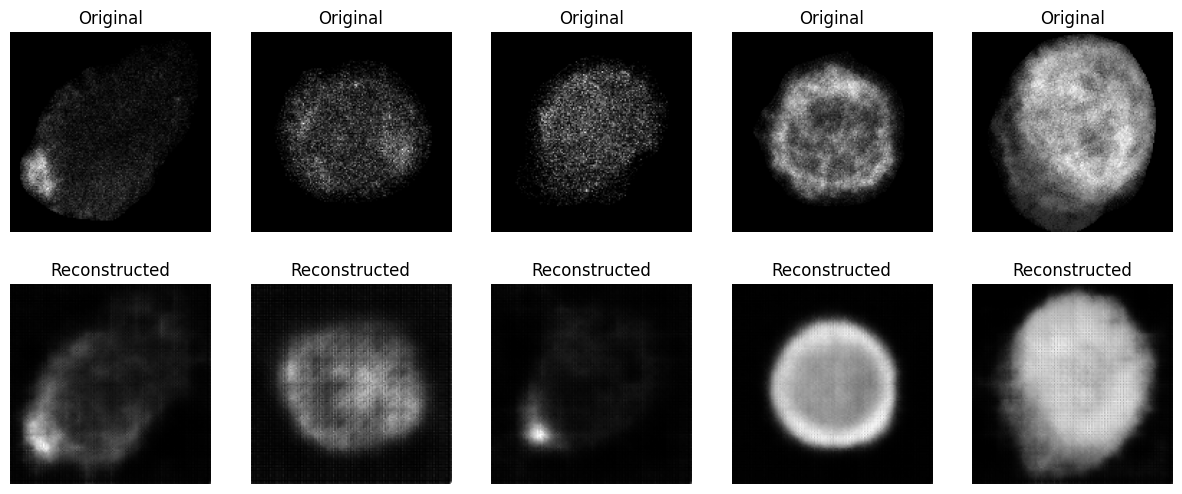

In [10]:
visualize_reconstructions(vae, btk_loader, device)

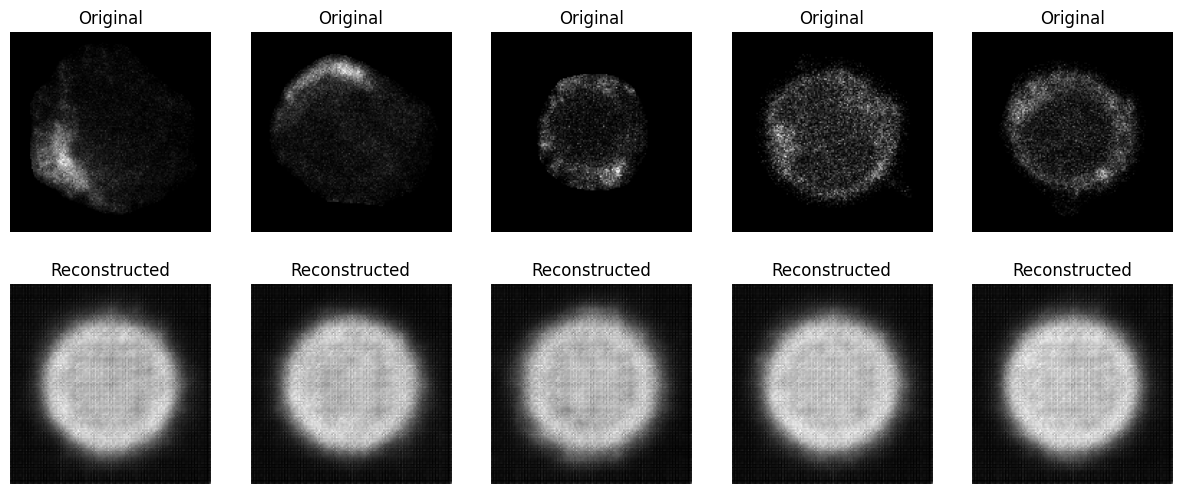

In [19]:
visualize_reconstructions(vae, btk_loader, device)

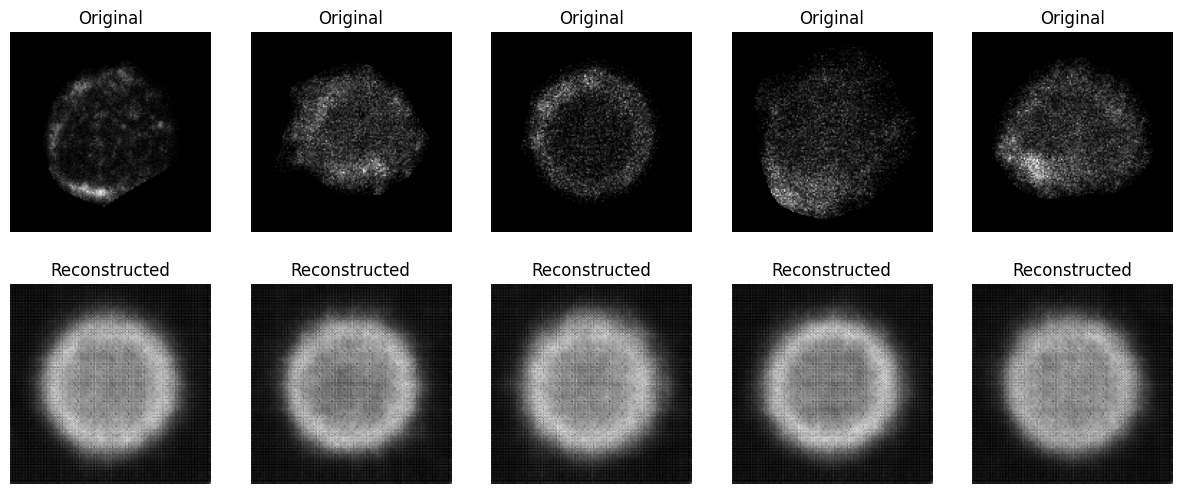

In [9]:
visualize_reconstructions(vae, btk_loader, device)

In [11]:
recon_images, _, _ = vae(images)

In [12]:
recon_images.shape

torch.Size([26, 2, 140, 140])

In [12]:
images.max()

tensor(1.)

In [13]:
reconstruction_losses

[76767.33504813058,
 10962.43275669643,
 6798.501700265067,
 5394.87684413365,
 5163.022086007254,
 4862.628832135882,
 4455.482169015067,
 4240.582349504743,
 4062.4937046595983,
 4021.070539202009,
 3771.9361877441406,
 3533.072283063616,
 3512.926945277623,
 3336.034916469029,
 3342.3732081821986,
 3235.180158342634,
 3328.1351274762833,
 3279.5253077915736,
 3136.4255894252233,
 3284.741241455078]

In [14]:
kl_losses

[115661.90779754093,
 67861.65304129464,
 80283.5105329241,
 47359.50927734375,
 51290.49571010045,
 605598.1884416853,
 24282.625,
 22689.236886160714,
 19016.10586983817,
 16039.972603934151,
 12470.337908063617,
 10274.471557617188,
 9093.956220354352,
 8299.992510114398,
 7404.612051827567,
 6659.254507882254,
 6171.414045061384,
 5996.455540248326,
 5743.82843889509,
 5419.53961617606]

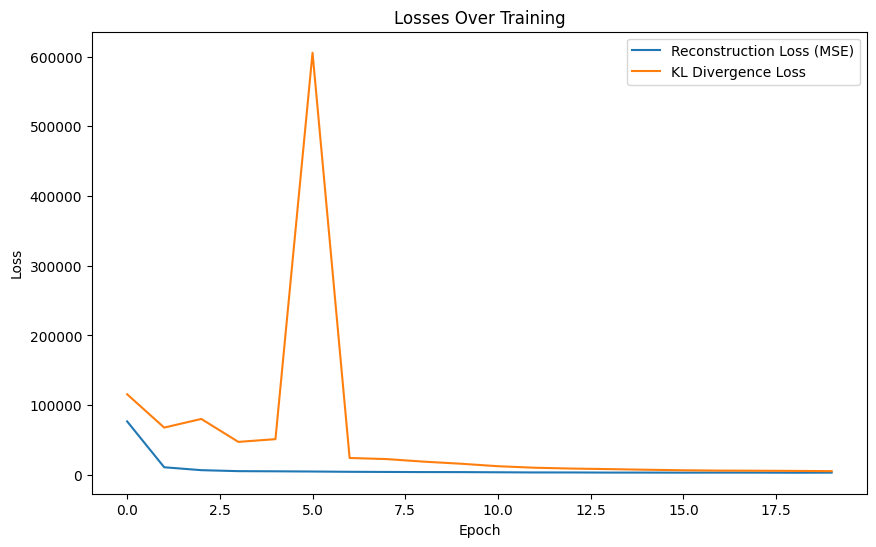

In [15]:
plt.figure(figsize=(10, 6))
#plt.plot(total_losses, label="Total Loss")
plt.plot(reconstruction_losses, label="Reconstruction Loss (MSE)")
plt.plot(kl_losses, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses Over Training")
plt.legend()
plt.show()